In [1]:
from konlpy.tag import Okt
import os

# 형태소 분석기 초기화
okt = Okt()

# 시놉시스 파일 목록
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 
             'synopsis_horror.txt', 'synopsis_etc.txt', 'synopsis_documentary.txt', 
             'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt', 
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 
             'synopsis_western.txt', 'synopsis_adult.txt', 'synopsis_thriller.txt', 
             'synopsis_animation.txt', 'synopsis_action.txt', 'synopsis_adventure.txt', 
             'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']

# 명사 추출 함수
def extract_nouns_from_file(file_path):
    """ 파일을 읽고 형태소 분석기로 명사만 추출 """
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    nouns = okt.nouns(text)  # 명사 추출
    return nouns

# 모든 장르의 명사 저장
genre_nouns = {}

for file in genre_txt:
    if os.path.exists(file):  # 파일 존재 여부 확인
        genre_nouns[file] = extract_nouns_from_file(file)
        print(f"{file} 처리 완료, {len(genre_nouns[file])}개 명사 추출됨.")
    else:
        print(f"파일 {file}을 찾을 수 없습니다.")

# 결과 확인 (예시: SF 장르)
print("SF 장르에서 추출된 명사 일부:", genre_nouns['synopsis_SF.txt'][:10])


synopsis_SF.txt 처리 완료, 21712개 명사 추출됨.
synopsis_family.txt 처리 완료, 8006개 명사 추출됨.
synopsis_show.txt 처리 완료, 7984개 명사 추출됨.
synopsis_horror.txt 처리 완료, 57799개 명사 추출됨.
synopsis_etc.txt 처리 완료, 49024개 명사 추출됨.
synopsis_documentary.txt 처리 완료, 156816개 명사 추출됨.
synopsis_drama.txt 처리 완료, 377560개 명사 추출됨.
synopsis_romance.txt 처리 완료, 102079개 명사 추출됨.
synopsis_musical.txt 처리 완료, 3442개 명사 추출됨.
synopsis_mystery.txt 처리 완료, 15726개 명사 추출됨.
synopsis_crime.txt 처리 완료, 29567개 명사 추출됨.
synopsis_historical.txt 처리 완료, 3621개 명사 추출됨.
synopsis_western.txt 처리 완료, 925개 명사 추출됨.
synopsis_adult.txt 처리 완료, 45228개 명사 추출됨.
synopsis_thriller.txt 처리 완료, 43044개 명사 추출됨.
synopsis_animation.txt 처리 완료, 121869개 명사 추출됨.
synopsis_action.txt 처리 완료, 115565개 명사 추출됨.
synopsis_adventure.txt 처리 완료, 9687개 명사 추출됨.
synopsis_war.txt 처리 완료, 8463개 명사 추출됨.
synopsis_comedy.txt 처리 완료, 107422개 명사 추출됨.
synopsis_fantasy.txt 처리 완료, 11992개 명사 추출됨.
SF 장르에서 추출된 명사 일부: ['시간', '지명', '알', '수', '한국', '가상', '도시', '산성비', '오염', '이']


In [4]:
from gensim.models import Word2Vec

# 장르별 명사 데이터를 리스트 형태로 변환
sentences = list(genre_nouns.values())

# Word2Vec 모델 학습 (CBOW 방식)
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=10, sg=0, workers=4)

# 학습된 모델 저장
w2v_model.save("word2vec_cbow.model")

# 특정 단어와 가장 유사한 단어 출력 (예: "영웅")
print(w2v_model.wv.most_similar("영웅", topn=10))


[('준비', 0.9997367262840271), ('손님', 0.9997296929359436), ('임무', 0.9997181296348572), ('시도', 0.9997099041938782), ('훈련', 0.9997057318687439), ('위', 0.9997049570083618), ('연구', 0.999704122543335), ('전쟁', 0.9997016787528992), ('군대', 0.9996992349624634), ('기회', 0.9996930360794067)]


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from gensim.models import Word2Vec
from collections import Counter

# 장르별 코퍼스 준비 (각 장르의 명사 리스트를 문자열로 변환)
genre_corpus = {genre: " ".join(words) for genre, words in genre_nouns.items()}

# TF-IDF 벡터라이저 초기화
vectorizer = TfidfVectorizer(max_features=1000)  # 상위 1000개 단어 사용
X = vectorizer.fit_transform(genre_corpus.values())

# 단어 리스트 추출
feature_names = np.array(vectorizer.get_feature_names_out())

# 장르별 상위 N개 단어 추출
N = 50
genre_keywords = {}

for genre, row in zip(genre_corpus.keys(), X.toarray()):
    # 가장 높은 TF-IDF 점수를 가진 N개 단어 선택
    top_indices = row.argsort()[-N:][::-1]
    top_words = feature_names[top_indices]
    
    genre_keywords[genre] = top_words

# 📌 중복 단어 자동 제거 (여러 장르에서 등장한 단어 필터링)
word_counts = Counter(word for words in genre_keywords.values() for word in words)

filtered_keywords = {}
for genre, words in genre_keywords.items():
    filtered_keywords[genre] = [word for word in words if word_counts[word] == 1]  # 다른 장르에서 안 쓰인 단어만 유지

# 📌 Word2Vec을 활용한 의미적 중복 단어 제거
sentences = list(genre_nouns.values())  # Word2Vec 학습용 데이터
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=10, sg=0, workers=4)

final_keywords = {}
for genre, words in filtered_keywords.items():
    unique_words = []
    for word in words:
        if all(w2v_model.wv.similarity(word, w) < 0.85 for w in unique_words):  # 0.85 이상 유사한 단어는 중복으로 간주
            unique_words.append(word)
    final_keywords[genre] = unique_words

# ✅ 최종 결과 확인
for genre, words in final_keywords.items():
    print(f"{genre}: {words[:10]}")  # 각 장르별 대표 단어 10개 출력


synopsis_SF.txt: ['인류']
synopsis_family.txt: ['아빠']
synopsis_show.txt: ['연인']
synopsis_horror.txt: ['좀비']
synopsis_etc.txt: ['독립']
synopsis_documentary.txt: ['다큐', '사회']
synopsis_drama.txt: []
synopsis_romance.txt: ['연애']
synopsis_musical.txt: ['스페인']
synopsis_mystery.txt: ['미스터리']
synopsis_crime.txt: []
synopsis_historical.txt: ['조선']
synopsis_western.txt: ['헨리']
synopsis_adult.txt: ['마사지']
synopsis_thriller.txt: []
synopsis_animation.txt: ['애니메이션', '최강']
synopsis_action.txt: ['납치']
synopsis_adventure.txt: ['여정']
synopsis_war.txt: ['부대']
synopsis_comedy.txt: ['인생']
synopsis_fantasy.txt: ['알렉스', '판타스틱']


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from gensim.models import Word2Vec
from collections import Counter

# 장르별 코퍼스 준비 (각 장르의 명사 리스트를 문자열로 변환)
genre_corpus = {genre: " ".join(words) for genre, words in genre_nouns.items()}

# TF-IDF 벡터라이저 초기화 (최대 단어 수 증가)
vectorizer = TfidfVectorizer(max_features=2000)  # 상위 2000개 단어 사용
X = vectorizer.fit_transform(genre_corpus.values())

# 단어 리스트 추출
feature_names = np.array(vectorizer.get_feature_names_out())

# 장르별 상위 N개 단어 추출
N = 100  # 상위 100개 단어 선택
genre_keywords = {}

for genre, row in zip(genre_corpus.keys(), X.toarray()):
    # 가장 높은 TF-IDF 점수를 가진 N개 단어 선택
    top_indices = row.argsort()[-N:][::-1]
    top_words = feature_names[top_indices]
    
    genre_keywords[genre] = top_words

# 📌 중복 단어 자동 제거 (여러 장르에서 등장한 단어 필터링, 등장 빈도 1 초과 단어 포함)
word_counts = Counter(word for words in genre_keywords.values() for word in words)

filtered_keywords = {}
for genre, words in genre_keywords.items():
    filtered_keywords[genre] = [word for word in words if word_counts[word] <= 3]  # 여러 장르에서 등장한 단어 제한

# 📌 Word2Vec을 활용한 의미적 중복 단어 제거
sentences = list(genre_nouns.values())  # Word2Vec 학습용 데이터
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=5, sg=0, workers=4)

final_keywords = {}
for genre, words in filtered_keywords.items():
    unique_words = []
    for word in words:
        if all(w2v_model.wv.similarity(word, w) < 0.85 for w in unique_words):  # 유사도가 0.85 이상이면 중복 제거
            unique_words.append(word)
    final_keywords[genre] = unique_words

# ✅ 최종 결과 확인
for genre, words in final_keywords.items():
    print(f"{genre}: {words[:10]}")  # 각 장르별 대표 단어 10개 출력


synopsis_SF.txt: ['인류']
synopsis_family.txt: ['어머니', '부산']
synopsis_show.txt: ['오페라']
synopsis_horror.txt: ['공포']
synopsis_etc.txt: ['뉴미디어', '연출']
synopsis_documentary.txt: ['다큐', '과정']
synopsis_drama.txt: ['연출', '독립']
synopsis_romance.txt: ['섹스']
synopsis_musical.txt: ['뮤지컬', '몰래']
synopsis_mystery.txt: ['진실']
synopsis_crime.txt: ['범죄']
synopsis_historical.txt: ['조선']
synopsis_western.txt: ['서부']
synopsis_adult.txt: ['마사지']
synopsis_thriller.txt: ['진실']
synopsis_animation.txt: ['애니메이션', '애니', '도롱']
synopsis_action.txt: ['임무']
synopsis_adventure.txt: ['여정']
synopsis_war.txt: ['독일군']
synopsis_comedy.txt: ['코미디']
synopsis_fantasy.txt: ['요괴']



=== WEAT Score 결과 ===
SF: -0.0545
가족: 0.0482
공연: -0.0142
공포: -0.0649
기타: 0.0870
다큐멘터리: 0.0274
드라마: 0.0476
로맨스: -0.0526
뮤지컬: 0.0089
미스터리: -0.0678
범죄: -0.0317
사극: -0.0396
서부극: -0.0204
성인물: -0.0439
스릴러: -0.0678
애니메이션: 0.0483
액션: -0.0441
어드벤처: -0.0378
전쟁: -0.0366
코미디: -0.0279
판타지: -0.0542


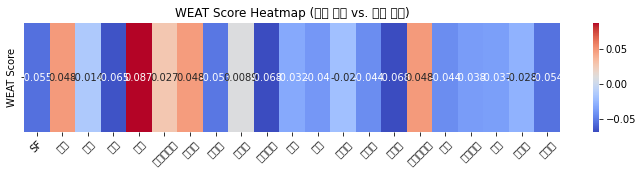

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ 속성 단어 그룹 정의 (예술 영화 vs 상업 영화)
attribute_words_A = ["예술", "작품", "감독", "독립", "실험", "미학"]  # 예술 영화 관련 단어
attribute_words_B = ["흥행", "대중", "상업", "오락", "히트", "블록버스터"]  # 상업 영화 관련 단어

# ✅ 장르별 대표 단어 (Target Words)
target_words = {
    "SF": ["인류"],
    "가족": ["어머니", "부산"],
    "공연": ["오페라"],
    "공포": ["공포"],
    "기타": ["뉴미디어", "연출"],
    "다큐멘터리": ["다큐", "과정"],
    "드라마": ["연출", "독립"],
    "로맨스": ["섹스"],
    "뮤지컬": ["뮤지컬", "몰래"],
    "미스터리": ["진실"],
    "범죄": ["범죄"],
    "사극": ["조선"],
    "서부극": ["서부"],
    "성인물": ["마사지"],
    "스릴러": ["진실"],
    "애니메이션": ["애니메이션", "애니", "도롱"],
    "액션": ["임무"],
    "어드벤처": ["여정"],
    "전쟁": ["독일군"],
    "코미디": ["코미디"],
    "판타지": ["요괴"],
}

# ✅ WEAT Score 계산 함수
def compute_weat_score(target_words, attr_A, attr_B, model):
    scores = []
    for word in target_words:
        if word in model.wv:
            mean_A = np.mean([model.wv.similarity(word, a) for a in attr_A if a in model.wv])
            mean_B = np.mean([model.wv.similarity(word, b) for b in attr_B if b in model.wv])
            score = mean_A - mean_B
            scores.append(score)
    return np.mean(scores) if scores else 0  # 단어가 없으면 0 반환

# ✅ 모든 장르의 WEAT Score 계산
weat_scores = {genre: compute_weat_score(words, attribute_words_A, attribute_words_B, w2v_model) for genre, words in target_words.items()}

# ✅ 텍스트로 WEAT Score 출력
print("\n=== WEAT Score 결과 ===")
for genre, score in weat_scores.items():
    print(f"{genre}: {score:.4f}")

# ✅ 시각화를 위한 데이터 변환
heatmap_data = np.array(list(weat_scores.values())).reshape(1, -1)
genres = list(weat_scores.keys())

# ✅ WEAT Score Heatmap 시각화
plt.figure(figsize=(12, 2))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", xticklabels=genres, yticklabels=["WEAT Score"])
plt.xticks(rotation=45)
plt.title("WEAT Score Heatmap (예술 영화 vs. 상업 영화)")
plt.show()


##### 예술 영화 성향이 강한 장르 (WEAT Score 양수)  
##### 기타(0.0870), 가족(0.0482), 드라마(0.0476), 애니메이션(0.0483)

##### 상업 영화 성향이 강한 장르 (WEAT Score 음수)  
##### SF(-0.0545), 공포(-0.0649), 로맨스(-0.0526), 액션(-0.0441), 판타지(-0.0542), 미스터리(-0.0678), 스릴러(-0.0678)

##### 드라마와 다큐멘터리는 예술 영화 성향이 있을 것으로 예상했으며, 실제로 양수를 가짐.  
##### 공포, 스릴러, 액션, SF는 상업적 성향이 강할 것으로 예상했으며, 실제로 음수를 가짐.  
##### 예상과 다르게 판타지(-0.0542), 애니메이션(0.0483)의 성향이 비교적 애매한 결과를 보임.  
##### 판타지는 예술성이 높은 작품들도 많지만, 대중적인 요소도 강해서 균형을 이루는 것으로 보임.  
##### 애니메이션은 특정 예술적 작품들이 영향을 줬을 가능성이 있음.


=== 성별 편향 WEAT Score 결과 ===
SF: -0.0088
가족: -0.0281
공연: -0.0180
공포: -0.0064
기타: -0.0350
다큐멘터리: -0.0260
드라마: -0.0297
로맨스: -0.0092
뮤지컬: -0.0220
미스터리: -0.0060
범죄: -0.0142
사극: -0.0125
서부극: -0.0170
성인물: -0.0113
스릴러: -0.0060
애니메이션: -0.0235
액션: -0.0113
어드벤처: -0.0127
전쟁: -0.0131
코미디: -0.0150
판타지: -0.0090


/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 45224 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 50668 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 45224 missing from current font.
  font.set_text(s, 0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 50668 missing from current font.
  font.set_text(s, 0, flags=flags)


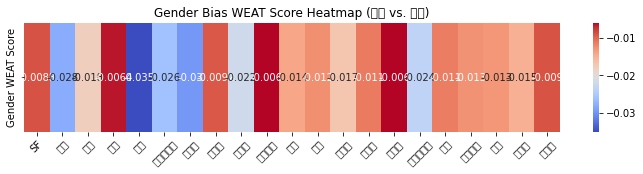

In [10]:
# ✅ 속성 단어 그룹 (남성 vs. 여성)
attribute_words_male = ["전쟁", "강인한", "리더", "힘", "도전", "모험", "폭력", "무기"]
attribute_words_female = ["사랑", "감성", "부드러운", "가족", "희생", "평화", "배려", "눈물"]

# ✅ 모든 장르의 WEAT Score 계산 (남성 vs. 여성 성향)
weat_scores_gender = {genre: compute_weat_score(words, attribute_words_female, attribute_words_male, w2v_model) for genre, words in target_words.items()}

# ✅ 텍스트 출력
print("\n=== 성별 편향 WEAT Score 결과 ===")
for genre, score in weat_scores_gender.items():
    print(f"{genre}: {score:.4f}")

# ✅ 시각화를 위한 데이터 변환
heatmap_data_gender = np.array(list(weat_scores_gender.values())).reshape(1, -1)
genres = list(weat_scores_gender.keys())

# ✅ Heatmap 시각화
plt.figure(figsize=(12, 2))
sns.heatmap(heatmap_data_gender, annot=True, cmap="coolwarm", xticklabels=genres, yticklabels=["Gender WEAT Score"])
plt.xticks(rotation=45)
plt.title("Gender Bias WEAT Score Heatmap (남성 vs. 여성)")
plt.show()


##### 극단적인 편향이 나타나지 않음  
##### 영화 장르가 남성적/여성적 성향과는 연관성이 적음  
##### 다큐멘터리(-0.0260), 드라마(-0.0297), 가족(-0.0281) 장르가 약간 남성적 성향을 띔.  

##### 로맨스(-0.0092), 코미디(-0.0150), 판타지(-0.0090)도 약간 남성적 성향  

##### 보통 로맨스나 코미디는 여성적 성향을 가질 것으로 예상, 실제 WEAT Score는 오히려 중립 또는 약간 남성적 성향.  


=== 국가별 영화 성향 WEAT Score 결과 ===
SF: -0.0484
가족: 0.0108
공연: -0.0263
공포: -0.0540
기타: 0.0330
다큐멘터리: -0.0023
드라마: 0.0089
로맨스: -0.0472
뮤지컬: -0.0130
미스터리: -0.0554
범죄: -0.0360
사극: -0.0402
서부극: -0.0291
성인물: -0.0422
스릴러: -0.0554
애니메이션: 0.0145
액션: -0.0428
어드벤처: -0.0394
전쟁: -0.0387
코미디: -0.0341
판타지: -0.0483


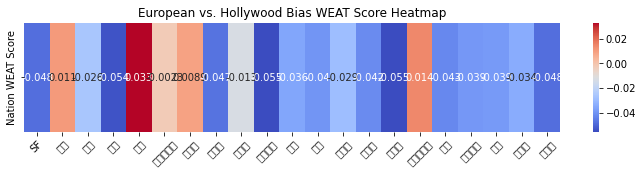

In [11]:
# ✅ 속성 단어 그룹 (유럽 vs. 할리우드)
attribute_words_europe = ["예술", "철학", "실험", "상징", "미장센", "작가주의", "독립"]
attribute_words_hollywood = ["오락", "흥행", "블록버스터", "액션", "히트", "대중", "스타"]

# ✅ 모든 장르의 WEAT Score 계산 (유럽 vs. 할리우드 성향)
weat_scores_nation = {genre: compute_weat_score(words, attribute_words_europe, attribute_words_hollywood, w2v_model) for genre, words in target_words.items()}

# ✅ 텍스트 출력
print("\n=== 국가별 영화 성향 WEAT Score 결과 ===")
for genre, score in weat_scores_nation.items():
    print(f"{genre}: {score:.4f}")

# ✅ 시각화를 위한 데이터 변환
heatmap_data_nation = np.array(list(weat_scores_nation.values())).reshape(1, -1)
genres = list(weat_scores_nation.keys())

# ✅ Heatmap 시각화
plt.figure(figsize=(12, 2))
sns.heatmap(heatmap_data_nation, annot=True, cmap="coolwarm", xticklabels=genres, yticklabels=["Nation WEAT Score"])
plt.xticks(rotation=45)
plt.title("European vs. Hollywood Bias WEAT Score Heatmap")
plt.show()


##### 공포(-0.0540), 미스터리(-0.0554), 스릴러(-0.0554)  
##### 흥행성과 대중성이 높은 장르, 유럽보다는 할리우드 스타일의 상업 영화로 소비  
##### SF(-0.0484), 로맨스(-0.0472), 판타지(-0.0483), 액션(-0.0428)
##### 할리우드 블록버스터 스타일이 강한 장르들  

##### 기타(0.0330), 가족(0.0108), 드라마(0.0089), 애니메이션(0.0145)  
##### 실험적이거나 독립 영화 성향이 강한 장르  
##### 다큐멘터리는 거의 중립적인 값(-0.0023)  
##### 유럽과 할리우드에서 모두 비슷한 비율로 제작   

##### 뮤지컬(-0.0130), 서부극(-0.0291), 코미디(-0.0341)  
##### 미국의 할리우드 스타일이지만, 유럽에서도 제작되는 장르  

/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 44032 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 51313 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 44277 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 50672 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 54252 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 44592 missing from current font.
  font.set_

/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 49436 missing from current font.
  font.set_text(s, 0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 48512 missing from current font.
  font.set_text(s, 0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 49457 missing from current font.
  font.set_text(s, 0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 51064 missing from current font.
  font.set_text(s, 0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 47932 missing from current font.
  font.set_text(s, 0, flags=flags)
/opt/conda/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 47540 missing from current font.
  font.set_text(s, 0,

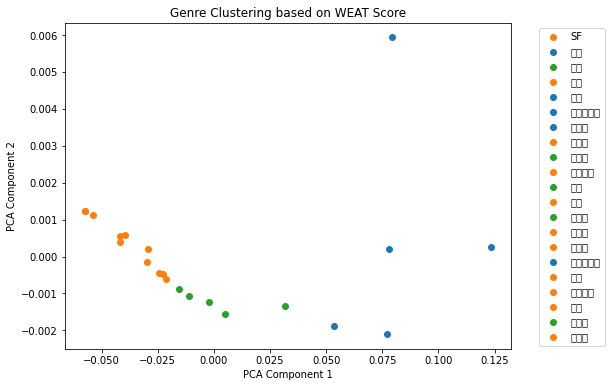

In [12]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ✅ WEAT Score 벡터화 (성별, 국가, 예술 vs. 상업 영화 포함)
weat_matrix = np.array([
    [weat_scores[genre], weat_scores_gender[genre], weat_scores_nation[genre]]
    for genre in target_words.keys()
])

# ✅ PCA 적용 (차원 축소)
pca = PCA(n_components=2)
weat_pca = pca.fit_transform(weat_matrix)

# ✅ K-Means 클러스터링 (3개의 그룹)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(weat_pca)

# ✅ 클러스터링 시각화
plt.figure(figsize=(8, 6))
for i, genre in enumerate(target_words.keys()):
    plt.scatter(weat_pca[i, 0], weat_pca[i, 1], label=genre, c=f"C{labels[i]}")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Genre Clustering based on WEAT Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


 최종 결론 및 시사점  
 -  
 -  
 - 
   
예술성과 상업성이 강한 장르는 명확한 경향을 보인다.  

SF, 공포, 미스터리, 스릴러, 액션은 상업적 경향이 강함.  
다큐멘터리, 드라마, 가족 영화는 예술 영화 성향이 있음.   
성별 편향은 크지 않으나, 예상과 다른 결과도 존재함.   

예상과 달리 로맨스/코미디가 중립적이거나 약간 남성적 성향을 가짐.  
유럽과 할리우드 영화의 차이가 명확함.  

공포, 액션, SF, 스릴러는 할리우드 스타일이 강함.  
드라마, 애니메이션, 가족 영화는 유럽 영화 스타일이 강함.  
다큐멘터리는 중립적.  

앞으로의 개선 방향  
-
-
-

더 다양한 속성 단어를 실험하여 WEAT Score의 정확도를 높일 필요가 있음.  
다른 영화 데이터셋(예: IMDb, Netflix 데이터)과 비교하여 동일한 패턴이 나타나는지 분석 가능.  
영화 리뷰 데이터를 활용하여 감성 분석을 추가하면, 영화 장르별 감성 편향도 분석 가능.  
배우/감독/제작사별 편향 분석, 영화 리뷰 데이터와 결합한 분석 등 추가 연구를 진행할 수 있음.   
딥러닝 기반의 더 정교한 워드 임베딩 모델(FastText, BERT)도 실험해볼 가치가 있음.  

